In [2]:
import pandas as pd
import os
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

In [3]:
"""
Notes for what each trial is
trial 2: 500 gens, only ternary tournament for elites, no n-elites
trial 3: 500 gens, ternary tournament + best elite out of population and offspring
trials 4,5,6,7: repeat of trial 2, no n-elites

Next steps:
wrap up trial 2
then run 4, 5, 6, 7
trial 3 is already running
(ok so trials 4,5,6,7 did not actually run.
And trials 2 and 3 are running for over 500 gens... They should have stopped by now. Not sure why they didn't)
Ok so the HPC was on commit e3c5fdaafb81e5f7378f2a868c3b72abcbd23731 while my pc was on f00ceeb2c40519888665bbdb1cfc6e1ac2619ed5

"""

"\nNotes for what each trial is\ntrial 2: 500 gens, only ternary tournament for elites, no n-elites\ntrial 3: 500 gens, ternary tournament + best elite out of population and offspring\ntrials 4,5,6,7: repeat of trial 2, no n-elites\n\nNext steps:\nwrap up trial 2\nthen run 4, 5, 6, 7\ntrial 3 is already running\n(ok so trials 4,5,6,7 did not actually run.\nAnd trials 2 and 3 are running for over 500 gens... They should have stopped by now. Not sure why they didn't)\nOk so the HPC was on commit e3c5fdaafb81e5f7378f2a868c3b72abcbd23731 while my pc was on f00ceeb2c40519888665bbdb1cfc6e1ac2619ed5\n\n"

In [4]:
def get_gen_number(generation_dir):
    return int(re.split('_|\\.', generation_dir.name)[1])

In [5]:
def get_fits(trial_dir):
    # Each generation_dir is the csv write-out for one generation. Includes parameters and fitness of each individual
    # Ignore the final csv because it is not complete. Only includes header
    generation_dirs = [trial_dir / name for name in os.listdir(trial_dir)]
    # Sort according to generation number
    generation_dirs.sort(key = lambda dir_ : get_gen_number(dir_))
    # Load in each csv as a dataframe
    dfs = [pd.read_csv(dir_) for dir_ in generation_dirs[:-1]]
    all_fits =  [df['fitness'].to_list() for df in dfs]
    min_fits = [np.min(fits) for fits in all_fits]
    max_fits = [np.max(fits) for fits in all_fits]
    avg_fits = [np.average(fits) for fits in all_fits]
    std_fits = [np.std(fits) for fits in all_fits]
    return all_fits, min_fits, max_fits, avg_fits, std_fits

(0.0, 20.0)

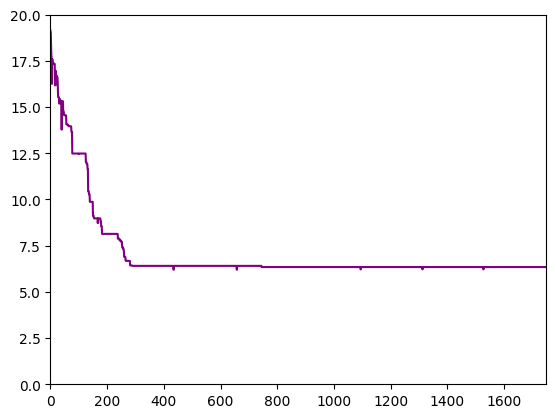

In [ ]:
trial_dir = Path(os.path.expanduser('~/hpc-share/uvms/preliminary/charlie/trial_2'))
all_fits, min_fits, max_fits, avg_fits, std_fits = get_fits(trial_dir)

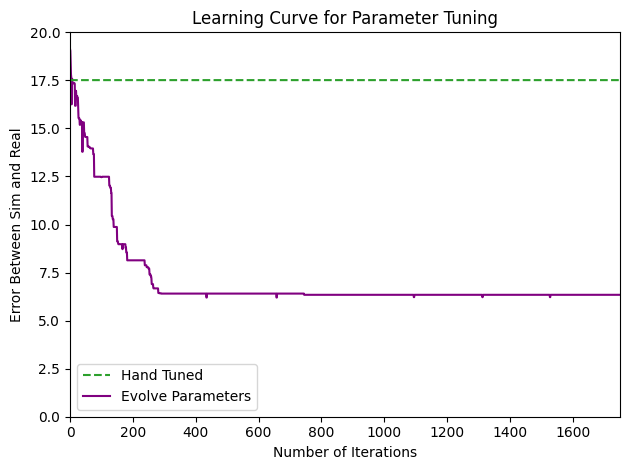

In [20]:
a, = plt.plot(min_fits, color='purple')
h, = plt.plot([17.5137907382116 for _ in range(len(min_fits))],'--', color='tab:green')
plt.ylabel("Error Between Sim and Real")
plt.xlabel("Number of Iterations")
plt.title("Learning Curve for Parameter Tuning")
plt.xlim(0, 22)
plt.ylim(0,20)
plt.xlim([0,1750])
plt.ylim([0,20])
plt.tight_layout()

plt.legend([h, a],["Hand Tuned", "Evolve Parameters"])
plt.savefig('many_gens.png')

(0.0, 20.0)

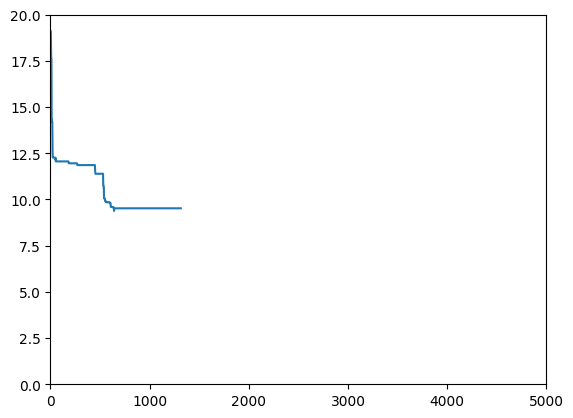

In [7]:
trial_dir = Path(os.path.expanduser('~/hpc-share/uvms/preliminary/charlie/trial_3'))
all_fits, min_fits, max_fits, avg_fits, std_fits = get_fits(trial_dir)
plt.plot(min_fits)
plt.xlim([0,5000])
plt.ylim([0,20])

In [ ]:
"""
Ok I'm on the right track. What trajectory did I train on?
That's specified in config["ea_parameters"]["trajectory_names"]
charlie trials 2 and 3 use _alt_001-0
How can I load learned parameters into the simulator?
I need a function in julia that loads in all the parameters, equivalent to
learn.py evalConfig()
"""

In [ ]:
# 500 gens is good
# I want to know how well a model generalizes once we've trained it to other trajectories
# and show a benchmark line of how well hannah's hand tuned model works

# Also curious how different

In [ ]:
# Maybe a good thing to do is 4 more that are like trial 2 (so 4, 5, 6, 7 are stat runs that repeat 2)
# Then compare that to each other, and to the handcoded parameters, first on the training trajectory

41.666666666666664